In [11]:
import pandas as pd
import numpy as np

matches = pd.read_csv('../data/raw/matches.csv')
deliveries = pd.read_csv('../data/raw/deliveries.csv')

print(matches.shape, deliveries.shape)

(1243, 10) (295732, 12)


In [12]:
from sqlalchemy import create_engine

engine = create_engine('sqlite:///../data/processed/cricket.db')

matches.to_sql('matches', engine, if_exists='replace', index=False)
deliveries.to_sql('deliveries', engine, if_exists='replace', index=False)

print("Database created: cricket.db")

Database created: cricket.db


In [2]:
print(matches.info())
print(deliveries.info())

<class 'pandas.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   match_id       1243 non-null   int64
 1   date           1243 non-null   str  
 2   city           1192 non-null   str  
 3   venue          1243 non-null   str  
 4   team1          1243 non-null   str  
 5   team2          1243 non-null   str  
 6   toss_winner    1243 non-null   str  
 7   toss_decision  1243 non-null   str  
 8   winner         1243 non-null   str  
 9   season         1243 non-null   str  
dtypes: int64(1), str(9)
memory usage: 250.7 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 295732 entries, 0 to 295731
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          295732 non-null  int64
 1   inning            295732 non-null  int64
 2   batting_team      295732 non-null  str  
 3   over        

In [3]:
matches.head()

,match_id,date,city,venue,team1,team2,toss_winner,toss_decision,winner,season
0,1,2017-04-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,2017
1,2,2017-04-06,Pune,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,Rising Pune Supergiant,2017
2,3,2017-04-07,Rajkot,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,2017
3,4,2017-04-08,Indore,Holkar Cricket Stadium,Kings XI Punjab,Rising Pune Supergiant,Kings XI Punjab,field,Kings XI Punjab,2017
4,5,2017-04-08,Bengaluru,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,Royal Challengers Bangalore,2017


In [4]:
deliveries.head()

,match_id,inning,batting_team,over,ball,batsman,bowler,batsman_runs,extra_runs,total_runs,dismissal_kind,player_dismissed
0,1,1,Sunrisers Hyderabad,0,1,DA Warner,TS Mills,0,0,0,NaN,NaN
1,1,1,Sunrisers Hyderabad,0,2,DA Warner,TS Mills,0,0,0,NaN,NaN
2,1,1,Sunrisers Hyderabad,0,3,DA Warner,TS Mills,4,0,4,NaN,NaN
3,1,1,Sunrisers Hyderabad,0,4,DA Warner,TS Mills,0,0,0,NaN,NaN
4,1,1,Sunrisers Hyderabad,0,5,DA Warner,TS Mills,0,2,2,NaN,NaN


In [5]:
print(matches.isnull().sum())
print(deliveries.isnull().sum())

match_id          0
date              0
city             51
venue             0
team1             0
team2             0
toss_winner       0
toss_decision     0
winner            0
season            0
dtype: int64
match_id                 0
inning                   0
batting_team             0
over                     0
ball                     0
batsman                  0
bowler                   0
batsman_runs             0
extra_runs               0
total_runs               0
dismissal_kind      281027
player_dismissed    281027
dtype: int64


In [6]:
# Fix inconsistent team names (common issue in these datasets)
team_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Deccan Chargers': 'Sunrisers Hyderabad'
}

for col in ['team1', 'team2', 'winner', 'toss_winner']:
    matches[col] = matches[col].replace(team_map)

for col in ['batting_team']:
    deliveries[col] = deliveries[col].replace(team_map)

# Handle nulls
matches['winner'] = matches['winner'].fillna('No Result')
matches['city'] = matches['city'].fillna('Unknown')

# Convert date
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')
matches['year'] = matches['date'].dt.year

# Drop duplicates
matches = matches.drop_duplicates()
deliveries = deliveries.drop_duplicates()

print("Cleaned. Final shapes:", matches.shape, deliveries.shape)

Cleaned. Final shapes: (1243, 11) (295732, 12)


In [7]:
import os
os.makedirs('../data/processed', exist_ok=True)

matches.to_csv('../data/processed/matches_clean.csv', index=False)
deliveries.to_csv('../data/processed/deliveries_clean.csv', index=False)

print("Saved to data/processed/")

Saved to data/processed/


In [8]:
matches.head()

,match_id,date,city,venue,team1,team2,toss_winner,toss_decision,winner,season,year
0,1,2017-04-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,2017,2017
1,2,2017-04-06,Pune,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,Rising Pune Supergiant,2017,2017
2,3,2017-04-07,Rajkot,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,2017,2017
3,4,2017-04-08,Indore,Holkar Cricket Stadium,Punjab Kings,Rising Pune Supergiant,Punjab Kings,field,Punjab Kings,2017,2017
4,5,2017-04-08,Bengaluru,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore,bat,Royal Challengers Bangalore,2017,2017


In [9]:
print(matches.columns.tolist())

['match_id', 'date', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'season', 'year']


In [13]:
from sqlalchemy import create_engine

engine = create_engine('sqlite:///../data/processed/cricket.db')

matches.to_sql('matches', engine, if_exists='replace', index=False)
deliveries.to_sql('deliveries', engine, if_exists='replace', index=False)

print("Database created: cricket.db")

Database created: cricket.db


In [14]:
import pandas as pd

query1 = """
SELECT winner, COUNT(*) as wins
FROM matches
GROUP BY winner
ORDER BY wins DESC
LIMIT 10
"""
pd.read_sql(query1, engine)

,winner,wins
0,Mumbai Indians,155
1,Chennai Super Kings,148
2,Kolkata Knight Riders,140
3,Rajasthan Royals,123
4,Royal Challengers Bangalore,114
5,Sunrisers Hyderabad,102
6,Kings XI Punjab,85
7,Delhi Daredevils,67
8,Delhi Capitals,58
9,Gujarat Titans,47


In [15]:
query2 = """
SELECT batsman, SUM(batsman_runs) as total_runs, COUNT(DISTINCT match_id) as innings
FROM deliveries
GROUP BY batsman
ORDER BY total_runs DESC
LIMIT 10
"""
pd.read_sql(query2, engine)

,batsman,total_runs,innings
0,V Kohli,9346,275
1,RG Sharma,7331,275
2,S Dhawan,6769,221
3,DA Warner,6567,184
4,KL Rahul,5828,149
5,SK Raina,5536,200
6,MS Dhoni,5439,241
7,AM Rahane,5367,197
8,SV Samson,5181,185
9,AB de Villiers,5181,170


In [16]:
query3 = """
SELECT bowler, COUNT(*) as wickets
FROM deliveries
WHERE dismissal_kind IS NOT NULL 
  AND dismissal_kind NOT IN ('run out', 'retired hurt', 'obstructing the field')
GROUP BY bowler
ORDER BY wickets DESC
LIMIT 10
"""
pd.read_sql(query3, engine)

,bowler,wickets
0,YS Chahal,233
1,B Kumar,226
2,SP Narine,209
3,PP Chawla,192
4,JJ Bumrah,190
5,R Ashwin,187
6,DJ Bravo,183
7,RA Jadeja,180
8,Rashid Khan,179
9,A Mishra,174


In [17]:
query4 = """
SELECT toss_winner, toss_decision, COUNT(*) as count,
       SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END) as won_after_toss
FROM matches
GROUP BY toss_winner, toss_decision
ORDER BY count DESC
LIMIT 15
"""
pd.read_sql(query4, engine)

,toss_winner,toss_decision,count,won_after_toss
0,Mumbai Indians,field,104,55
1,Kolkata Knight Riders,field,93,52
2,Rajasthan Royals,field,89,48
3,Royal Challengers Bangalore,field,80,40
4,Chennai Super Kings,field,72,43
5,Chennai Super Kings,bat,61,36
6,Sunrisers Hyderabad,field,61,29
7,Kings XI Punjab,field,58,29
8,Mumbai Indians,bat,56,30
9,Delhi Capitals,field,53,27


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [19]:
plt.figure(figsize=(10,5))
matches['year'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Matches Played Per Season')
plt.xlabel('Year'); plt.ylabel('Matches')
plt.tight_layout()
plt.savefig('../reports/matches_per_season.png')
plt.show()

KeyError: 'year'

<Figure size 1000x500 with 0 Axes>

print(matches.columns.tolist())

In [20]:
matches = pd.read_csv('../data/raw/matches.csv')
deliveries = pd.read_csv('../data/raw/deliveries.csv')

In [21]:
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')
matches['year'] = matches['date'].dt.year

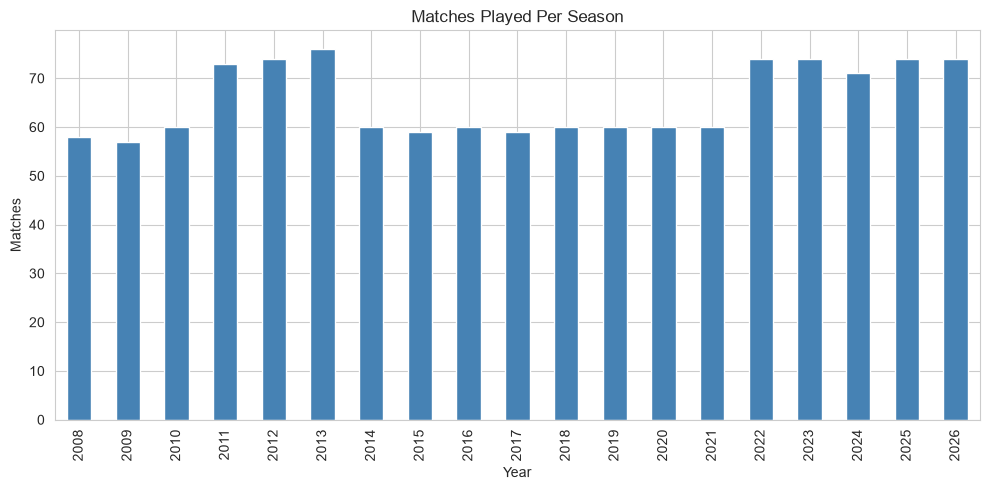

In [22]:
plt.figure(figsize=(10,5))
matches['year'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Matches Played Per Season')
plt.xlabel('Year'); plt.ylabel('Matches')
plt.tight_layout()
plt.savefig('../reports/matches_per_season.png')
plt.show()

In [23]:
toss_impact = matches.copy()
toss_impact['toss_win_match_win'] = toss_impact['toss_winner'] == toss_impact['winner']
win_rate = toss_impact['toss_win_match_win'].mean() * 100
print(f"Teams that won the toss also won the match {win_rate:.2f}% of the time")

Teams that won the toss also won the match 50.52% of the time


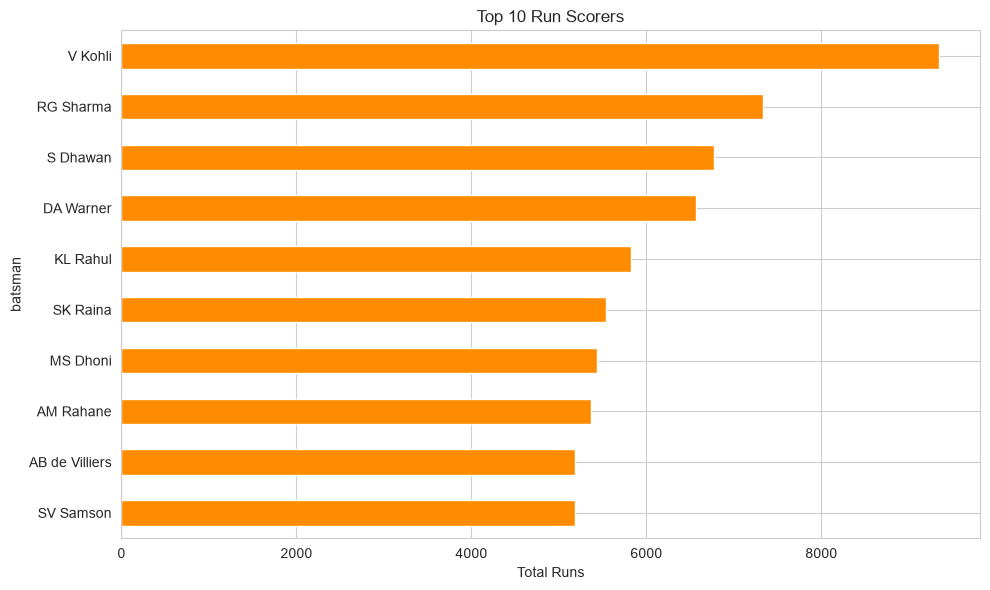

In [24]:
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_batsmen.plot(kind='barh', color='darkorange')
plt.title('Top 10 Run Scorers')
plt.xlabel('Total Runs')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/top_batsmen.png')
plt.show()

In [25]:
deliveries['phase'] = pd.cut(deliveries['over'], 
                               bins=[0,6,15,20], 
                               labels=['Powerplay','Middle','Death'])

phase_sr = deliveries.groupby(['phase'])['batsman_runs'].agg(['sum','count'])
phase_sr['strike_rate'] = (phase_sr['sum'] / phase_sr['count']) * 100
print(phase_sr)

              sum   count  strike_rate
phase                                 
Powerplay  115360   92367   124.893090
Middle     170497  135008   126.286590
Death       81039   52569   154.157393


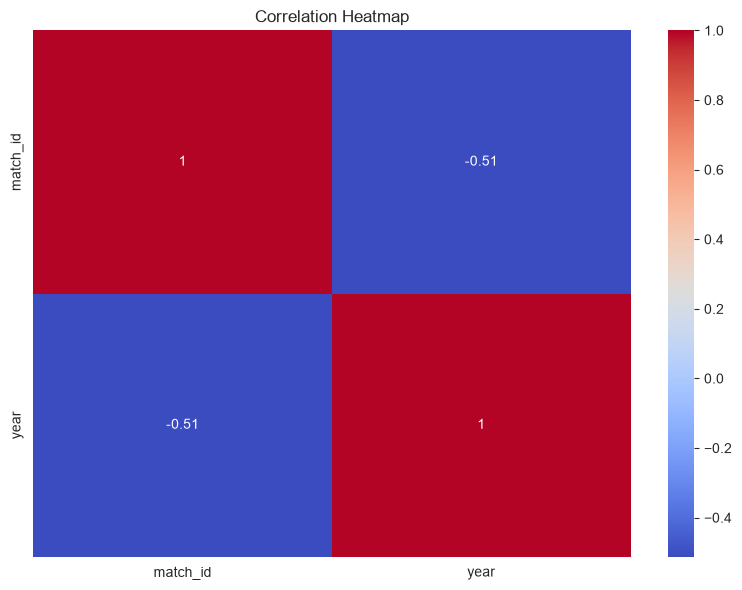

In [26]:
numeric_cols = matches.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png')
plt.show()

In [1]:
import pandas as pd
people = pd.read_csv('../data/raw/people.csv')
print(people.columns.tolist())
people.head()

['identifier', 'name', 'unique_name', 'key_bcci', 'key_bcci_2', 'key_bigbash', 'key_cricbuzz', 'key_cricheroes', 'key_crichq', 'key_cricinfo', 'key_cricinfo_2', 'key_cricinfo_3', 'key_cricingif', 'key_cricketarchive', 'key_cricketarchive_2', 'key_cricketworld', 'key_nvplay', 'key_nvplay_2', 'key_opta', 'key_opta_2', 'key_pulse', 'key_pulse_2']


,identifier,name,unique_name,key_bcci,key_bcci_2,key_bigbash,key_cricbuzz,key_cricheroes,key_crichq,key_cricinfo,...,key_cricingif,key_cricketarchive,key_cricketarchive_2,key_cricketworld,key_nvplay,key_nvplay_2,key_opta,key_opta_2,key_pulse,key_pulse_2
0,b4a23876,AAA Amsterdam,AAA Amsterdam,NaN,NaN,NaN,NaN,NaN,NaN,772407.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,482762af,AA Adeoye,AA Adeoye,NaN,NaN,NaN,NaN,NaN,NaN,380588.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4b0e3049,AA Alleyne,AA Alleyne,NaN,NaN,NaN,NaN,NaN,NaN,661441.0,...,NaN,1512811.0,NaN,NaN,NaN,NaN,NaN,NaN,18542.0,NaN
3,fd3c5c00,AAA Patel,AAA Patel,NaN,NaN,NaN,NaN,NaN,NaN,1163136.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,bc005f0d,AAA White,AAA White,NaN,NaN,NaN,NaN,NaN,NaN,474307.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
